# Spatial working memory spiking circuit model 

References:
J.D. Murray et al. Cerebral Cortex 2012
doi: 10.1093/cercor/bhs370

A. Compte, N. Brunel, P. Goldman-Rakic, X.-J. Wang Cerebral Cortex 2000
doi: 10.1093/cercor/10.9.910

Notice that with the Compte parameters, the spontaneous state takes ~10s
to reach its actual steady-state around 8Hz (not 3.5Hz).

In [1]:
from collections import OrderedDict
import random as pyrand

import numpy as np
import scipy.stats
import matplotlib.pyplot as plt

from numpy.fft import rfft, irfft

from brian2 import *




======================================================= 
### Helper function
    Compute the angle difference between theta1 and theta2 on a circle
 ======================================================

In [2]:
def angle_diff(theta1, theta2, mode='rad'):
    angle_circle = 2 * np.pi if mode == 'rad' else 360.0
    diff = abs(theta1 - theta2)
    return np.minimum(diff, angle_circle - diff)

 ======================================================
### Equations

=======================================================

In [3]:
equations = {}

equations['E'] = '''
dV/dt         = (-(V - V_L) + Isyn/gE) / tau_m_E : volt (unless refractory)
Isyn          = I_AMPA_ext + I_AMPA + I_NMDA + I_GABA + Istim : amp
I_AMPA_ext    = -gAMPA_ext_E * sAMPA_ext * (V - V_E) : amp
I_AMPA        = -gAMPA_E * S_AMPA * (V - V_E) : amp
I_NMDA        = -gNMDA_E * S_NMDA * (V - V_E) / (1 + exp(-a * V) / b) : amp
I_GABA        = -gGABA_E * S_GABA * (V - V_I) : amp
dsAMPA_ext/dt = -sAMPA_ext / tauAMPA : 1
dsAMPA/dt     = -sAMPA / tauAMPA : 1
dx/dt         = -x / tau_x : 1
dsNMDA/dt     = -sNMDA / tauNMDA + alpha * x * (1 - sNMDA) : 1

S_AMPA        : 1
S_NMDA        : 1
S_GABA        : 1
Istim         : amp

V_L           : volt (constant)
Vth           : volt (constant)
Vreset        : volt (constant)
gE            : siemens (constant)
tau_m_E       : second (constant)
V_E           : volt (constant)
V_I           : volt (constant)
a             : volt**-1 (constant)
b             : 1 (constant)
tauAMPA       : second (constant)
tau_x         : second (constant)
tauNMDA       : second (constant)
alpha         : Hz (constant)

gAMPA_ext_E   : siemens (constant)
gAMPA_E       : siemens (constant)
gNMDA_E       : siemens (constant)
gGABA_E       : siemens (constant)
'''

equations['I'] = '''
dV/dt         = (-(V - V_L) + Isyn/gI) / tau_m_I : volt (unless refractory)
Isyn          = I_AMPA_ext + I_AMPA + I_NMDA + I_GABA : amp
I_AMPA_ext    = -gAMPA_ext_I * sAMPA_ext * (V - V_E) : amp
I_AMPA        = -gAMPA_I * S_AMPA * (V - V_E) : amp
I_NMDA        = -gNMDA_I * S_NMDA * (V - V_E) / (1 + exp(-a * V) / b) : amp
I_GABA        = -gGABA_I * S_GABA * (V - V_I) : amp
dsAMPA_ext/dt = -sAMPA_ext / tauAMPA : 1
dsGABA/dt     = -sGABA / tauGABA : 1

S_AMPA        : 1
S_NMDA        : 1
S_GABA        : 1

V_L           : volt (constant)
Vth           : volt (constant)
Vreset        : volt (constant)
gI            : siemens (constant)
tau_m_I       : second (constant)
V_E           : volt (constant)
V_I           : volt (constant)
a             : volt**-1 (constant)
b             : 1 (constant)
tauAMPA       : second (constant)
tauGABA       : second (constant)

gAMPA_ext_I   : siemens (constant)
gAMPA_I       : siemens (constant)
gNMDA_I       : siemens (constant)
gGABA_I       : siemens (constant)
'''


=======================================================
### Model Parameters
 ======================================================

In [4]:
modelparams_common = dict(
#number of neurons
    N_E=2048,
    N_I=512,
#Common LIF
    V_L=-70 * mV,
    Vth=-50 * mV,
    Vreset=-60 * mV,
#Excitatory LIF
    gE=25 * nS,
    tau_m_E=20 * ms,
    tau_ref_E=2 * ms,
#Inhibitory LIF
    gI=20 * nS,
    tau_m_I=10 * ms,
    tau_ref_I=1 * ms,
#Reversal potentials
    V_E=0 * mV,
    V_I=-70 * mV,
#NMDA nonlinearity
    a=0.062 / mV,
    b=3.57,

# Synaptic time constants
    tauAMPA=2 * ms,
    tau_x=2 * ms,
    tauNMDA=100 * ms,
    alpha=0.5 * kHz,
    tauGABA=10 * ms
)


modelparams_compte = dict(
 # Unscaled recurrent synaptic conductances (excitatory)   
    gAMPA_E=0 * nS,
    gNMDA_E=0.381 * 2048 * nS,
    gGABA_E=1.336 * 512 * nS,
# Unscaled recurrent synaptic conductances (inhibitory)
    gAMPA_I=0 * nS,
    gNMDA_I=0.292 * 2048 * nS,
    gGABA_I=1.024 * 512 * nS,
# External synaptic conductances
    gAMPA_ext_E=3.1 * nS,
    gAMPA_ext_I=2.38 * nS,
# Background noise
    nu_ext=1.8 * kHz,
# Connectivity footprint
    sigma_EE=14.4,
    JEE_plus=1.62
)

modelparams_murray = dict(
# Unscaled recurrent synaptic conductances (excitatory)
    gAMPA_E=0 * nS,
    gNMDA_E=1001.9 * nS,
    gGABA_E=807.2 * nS,
# Unscaled recurrent synaptic conductances (inhibitory)
    gAMPA_I=0 * nS,
    gNMDA_I=717.6 * nS,
    gGABA_I=566.2 * nS,
 # External synaptic conductances
    gAMPA_ext_E=9.3 * nS,
    gAMPA_ext_I=7.14 * nS,
# Background noise
    nu_ext=0.6 * kHz,
# Connectivity footprint
    sigma_EE=9.0,
    JEE_plus=3.0
)

=======================================================
### Stimulus Parameters
=======================================================

In [5]:
stimparams = dict(
#Peak input strength

    Ipeak=375 * pA,

#input width and location
    sigma_stim=6.0,
    theta_stim=180.0,
#Input and offset
    Ton=500 * ms,
    Toff=750 * ms
)

 ======================================================
### Model
=======================================================

In [6]:

class Model:
    def __init__(self, modelparams, stimparams, dt=0.02 * ms):
       #---------------------------------------------------------------------------------
        # Initialize
        #--------------------------------------------------------------------------------- 
        
        # Create clocks
        clocks = OrderedDict()
        clocks['main'] = Clock(dt)
        clocks['nmda'] = Clock(dt * 10)
        clocks['mons'] = Clock(1.0 * ms)
        clocks['stim'] = Clock(10 * ms)
    #---------------------------------------------------------------------------------
    # Complete the model specification
    #---------------------------------------------------------------------------------

        #Model Parameters
        if isinstance(modelparams, str):
            params = modelparams_common.copy()
            if modelparams == 'compte':
                params.update(modelparams_compte)
            elif modelparams == 'murray':
                params.update(modelparams_murray)
            else:
                raise ValueError("Unknown modelparams string")
        elif isinstance(modelparams, dict):
            params = modelparams.copy()
        else:
            raise ValueError("Unknown modelparams type")


        # Rescale conductances by number of neurons
        for conductance in ['gAMPA_E', 'gAMPA_I', 'gNMDA_E', 'gNMDA_I']:
            params[conductance] /= params['N_E']
        for conductance in ['gGABA_E', 'gGABA_I']:
            params[conductance] /= params['N_I']

        net = OrderedDict()

        # neuron Populations

        # E/I populations
        net['E'] = NeuronGroup(
            params['N_E'],
            equations['E'],
            threshold='V > Vth',
            reset='V = Vreset',
            refractory=params['tau_ref_E'],
            clock=clocks['main'],
            method='euler',
        )

        net['I'] = NeuronGroup(
            params['N_I'],
            equations['I'],
            threshold='V > Vth',
            reset='V = Vreset',
            refractory=params['tau_ref_I'],
            clock=clocks['main'],
            method='euler',
        )

        # Assign parameters explicitly
        for key, value in params.items():
            if key in net['E'].variables:
                setattr(net['E'], key, value)
            if key in net['I'].variables:
                setattr(net['I'], key, value)

        #---------------------------------------------------------------------------------
        # Background input (post-synaptic)
        #--------------------------------------------------------------------
        for pop in ['E', 'I']:
            net['pg' + pop] = PoissonGroup(
                params['N_' + pop],
                rates=params['nu_ext'],
                clock=clocks['main']
            )
            net['ic' + pop] = Synapses(
                net['pg' + pop],
                net[pop],
                on_pre='sAMPA_ext += 1'
            )
            net['ic' + pop].connect(j='i')

        # ---------------------------------------------------------------------------------
        # Recurrent connections
        #---------------------------------------------------------------------------------
        
        
        # Presynaptic variables
        net['icAMPA'] = Synapses(net['E'], net['E'], on_pre='sAMPA += 1')
        net['icAMPA'].connect(j='i')

        net['icNMDA'] = Synapses(net['E'], net['E'], on_pre='x += 1')
        net['icNMDA'].connect(j='i')

        net['icGABA'] = Synapses(net['I'], net['I'], on_pre='sGABA += 1')
        net['icGABA'].connect(j='i')

        # Save early so operations can use self.*
        self.params = params
        self.stimparams = stimparams.copy()
        self.net = net
        self.clocks = clocks

        # # Recurrent NMDA connections
        N_E = params['N_E']
        JEE_plus = params['JEE_plus']
        sigma_EE = np.deg2rad(params['sigma_EE'])

        tmp = (2 * scipy.stats.norm.cdf(np.pi / sigma_EE) - 1) / np.sqrt(2 * np.pi) * sigma_EE
        JEE_minus = (1 - JEE_plus * tmp) / (1 - tmp)

        dtheta = 2 * np.pi * np.minimum(np.arange(N_E), N_E - np.arange(N_E)) / N_E
        w = JEE_minus + (JEE_plus - JEE_minus) * np.exp(-0.5 * dtheta**2 / sigma_EE**2)
        self.fw = rfft(w)


        # Recurrent NMDA connections
        @network_operation(when='start', clock=clocks['nmda'])
        def recurrent_NMDA():
            fsNMDA = rfft(net['E'].sNMDA[:])
            e_nmda = np.real(irfft(self.fw * fsNMDA, n=N_E))
            i_nmda = float(np.real(fsNMDA[0]))
            net['E'].S_NMDA = e_nmda
            net['I'].S_NMDA = np.ones(params['N_I']) * i_nmda


        # Recurrent GABA connections
        @network_operation(when='start', clock=clocks['main'])
        def recurrent_GABA():
            S = float(np.sum(net['I'].sGABA[:]))
            net['E'].S_GABA = np.ones(params['N_E']) * S
            net['I'].S_GABA = np.ones(params['N_I']) * S



        #Stimulis 
        @network_operation(when='start', clock=clocks['stim'])
        def stimulus():
            t = clocks['stim'].t
            if self.stimparams['Ton'] <= t < self.stimparams['Toff']:
                net['E'].Istim = self.Istim
            else:
                net['E'].Istim = np.zeros(params['N_E']) * amp

        self.recurrent_NMDA = recurrent_NMDA
        self.recurrent_GABA = recurrent_GABA
        self.stimulus = stimulus
        
        #---------------------------------------------------------------------------------
        # Record spikes
        #---------------------------------------------------------------------------------


        # Monitors
        mons = OrderedDict()
        var_list = ['S_AMPA', 'S_NMDA', 'S_GABA', 'V', 'I_AMPA', 'I_NMDA', 'I_GABA', 'Isyn']

        for pop in ['E', 'I']:
            mons['spike' + pop] = SpikeMonitor(net[pop], record=True)
            mons['pop' + pop] = PopulationRateMonitor(net[pop])
            for var in var_list:
                if var in net[pop].variables:
                    mons[var + pop] = StateMonitor(net[pop], var, record=True, clock=clocks['mons'])

        for var in ['x', 'sNMDA', 'Istim']:
            mons[var + 'E'] = StateMonitor(net['E'], var, record=True, clock=clocks['mons'])

        self.mons = mons

    def reinit(self, seed_value=123):
 #Re-initialize random number generators
    
        pyrand.seed(seed_value)
        np.random.seed(seed_value)
#Randomly initialize membrane potentials
        for pop in ['E', 'I']:
            self.net[pop].V = np.random.uniform(
                self.params['Vreset'] / mV,
                self.params['Vth'] / mV,
                size=self.params['N_' + pop]
            ) * mV
# Set synaptic variables to zero
        for var in ['sAMPA_ext', 'sAMPA', 'x', 'sNMDA', 'S_AMPA', 'S_NMDA', 'S_GABA']:
            if var in self.net['E'].variables:
                setattr(self.net['E'], var, 0)

        for var in ['sAMPA_ext', 'sGABA', 'S_AMPA', 'S_NMDA', 'S_GABA']:
            if var in self.net['I'].variables:
                setattr(self.net['I'], var, 0)

        self.net['E'].Istim = 0 * amp
 # Set stimulus
        N_E = self.params['N_E']
        dtheta = angle_diff(
            self.stimparams['theta_stim'],
            np.arange(N_E) / N_E * 360.0,
            mode='deg'
        )
        self.Istim = self.stimparams['Ipeak'] * np.exp(
            -dtheta**2 / (2 * self.stimparams['sigma_stim']**2)
        )


======================================================
### Run
=======================================================


WARNING    'dt' is an internal variable of group 'poissongroup_1', but also exists in the run namespace with the value 20. * usecond. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'dt' is an internal variable of group 'poissongroup', but also exists in the run namespace with the value 20. * usecond. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    Note that the synaptic pathway 'synapses_1_pre' will run on the clock of the group 'poissongroup_1' using a dt of 20. us. Either the Synapses object 'synapses_1' or the target 'neurongroup_1' (or both) are using a different dt. This might lead to unexpected results. In particular, all delays will be rounded to multiples of 20. us. If in doubt, try to ensure that 'poissongroup_1', 'synapses_1', and 'neurongroup_1' use the same dt. [brian2.synapses.synapses.synapses_dt_mismatch]
WARNING    Note that the synaptic pathway 'synapses_2_pre

Starting simulation at t=0. s for a duration of 3. s
1.0757 s (35%) simulated in 10s, estimated 18s remaining.
2.16444 s (72%) simulated in 20s, estimated 8s remaining.
3. s (100%) simulated in 27s


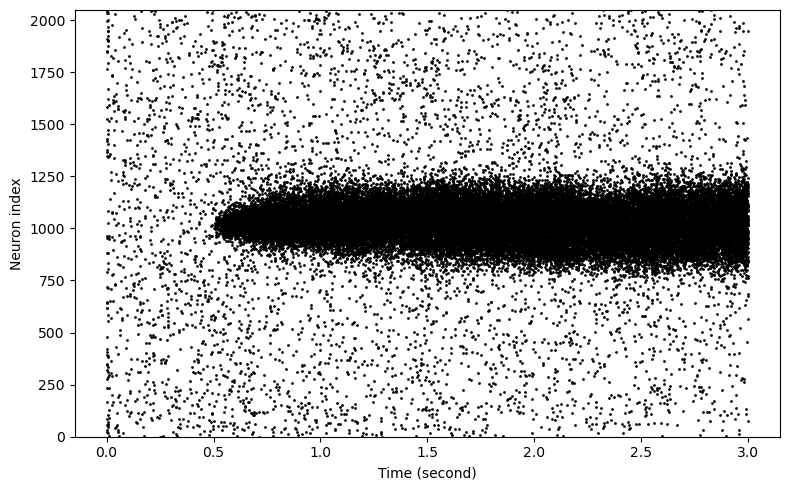

In [7]:

if __name__ == '__main__':
    dt = 0.02 * ms
    T = 3.0 * second
    modelparams = 'murray'

    model = Model(modelparams, stimparams, dt)

    network = Network(
        *list(model.net.values()),
        *list(model.mons.values()),
        model.recurrent_GABA,
        model.recurrent_NMDA,
        model.stimulus
    )
 # Setup the stimulus parameters for this trial (optional)
    model.stimparams['theta_stim'] = 180
    model.reinit(seed_value=1234)
    network.run(T, report='text')

    plt.figure(figsize=(8, 5))
    plt.plot(model.mons['spikeE'].t / second, model.mons['spikeE'].i, 'o', ms=2, mfc='k', mew=0)
    plt.ylim([0, model.params['N_E']])
    plt.xlabel('Time (second)')
    plt.ylabel('Neuron index')
    plt.tight_layout()
    plt.savefig('workingmemory_ringmodel.pdf')
    plt.show()